# V2 Pipeline - Phase 2: Huấn luyện Mô hình, Hyperparameter Tuning & Đánh giá Y tế (Dữ liệu MIMIC)

Thực hiện theo chỉ đạo chuyên môn trên bộ dữ liệu **MIMIC**:
1. **Tập trung Phân loại Nhị phân (Binary ML)**: Fine-tune **Logistic Regression** & **XGBoost** (khống chế `max_depth` từ 3 - 5 chống overfitting).
2. **Deep Learning (Neural Network / MLP)**: Thử nghiệm **Multi-Layer Perceptron** và **Hyperparameter Tuning** (`Learning Rate`, `Hidden Layer Sizes`, `Batch Size`, `Node Size`).
3. **Thước đo Y tế Chuyên biệt**: Đánh giá tập trung vào **Recall** (Tối thiểu hóa False Negative - ca bệnh bị bỏ sót), **F1-Score**, **Accuracy**, **Specificity**, và chỉ số **ROC-AUC**.
4. **Trực quan hóa**: Vẽ đường cong **ROC Curve** so sánh giữa các mô hình và **Confusion Matrix**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pyarrow
try:
    from tabpfn_client import TabPFNClassifier, init
    init()
    HAS_TABPFN = True
except Exception as e:
    HAS_TABPFN = False

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
import joblib

print('✅ Nạp thành công các thư viện Training, Tuning, TabPFN & Medical Metrics V2!')


Found existing access token, reusing it for authentication.

✅ Nạp thành công các thư viện Training, Tuning, TabPFN & Medical Metrics V2!


### 1. Nạp Dữ Liệu MIMIC V2 (Min-Max Scaled & Z-Score Scaled)

In [2]:
data_dir_candidates = ['../../data/features', 'data/features']
data_dir = next((d for d in data_dir_candidates if os.path.exists(os.path.join(d, 'v2_mimic_minmax_scaled.csv'))), '../../data/features')

df_minmax = pd.read_csv(os.path.join(data_dir, 'v2_mimic_minmax_scaled.csv'))
df_zscore = pd.read_csv(os.path.join(data_dir, 'v2_mimic_zscore_scaled.csv'))

X_mm = df_minmax.drop(columns=['status'])
y_mm = df_minmax['status']

X_zs = df_zscore.drop(columns=['status'])
y_zs = df_zscore['status']

# Tách tập Train / Test (80% Train, 20% Test - Stratified)
Xmm_train, Xmm_test, y_train, y_test = train_test_split(X_mm, y_mm, test_size=0.2, random_state=42, stratify=y_mm)
Xzs_train, Xzs_test, _, _ = train_test_split(X_zs, y_zs, test_size=0.2, random_state=42, stratify=y_zs)

print(f"Tập Train MIMIC: {len(y_train)} mẫu | Tập Test MIMIC: {len(y_test)} mẫu")
print(f"Số lượng đặc trưng đầu vào: {X_mm.shape[1]}")


Tập Train MIMIC: 961 mẫu | Tập Test MIMIC: 241 mẫu
Số lượng đặc trưng đầu vào: 16


# Khởi tạo và huấn luyện TabPFN (nếu sẵn sàng)
tabpfn_model = None
if HAS_TABPFN:
    try:
        clf_tab = TabPFNClassifier()
        clf_tab.fit(Xmm_train.values, y_train.values)
        tabpfn_model = clf_tab
        print('✅ Fit thành công TabPFNClassifier!')
    except Exception as ex:
        print(f'❌ TabPFN Lỗi: {ex}')

all_models = {
    'Logistic Regression (Tuned)': (best_lr, Xzs_test),
    'XGBoost (Tuned Depth)': (best_xgb, Xmm_test),
    'Neural Network / MLP (Tuned)': (best_mlp, Xmm_test),
    'LightGBM': (lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=200, learning_rate=0.05, max_depth=5).fit(Xmm_train, y_train), Xmm_test),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42).fit(Xmm_train, y_train), Xmm_test),
    'Extra Trees': (ExtraTreesClassifier(n_estimators=200, max_depth=5, random_state=42).fit(Xmm_train, y_train), Xmm_test),
    'SVM (RBF Kernel)': (SVC(probability=True, random_state=42).fit(Xzs_train, y_train), Xzs_test),
    'KNN': (KNeighborsClassifier(n_neighbors=5).fit(Xmm_train, y_train), Xmm_test)
}

if tabpfn_model is not None:
    all_models['TabPFN'] = (tabpfn_model, Xmm_test.values)

eval_results = []
roc_data = {}
conf_matrices = {}

for name, (model, X_test_set) in all_models.items():
    y_pred = model.predict(X_test_set)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_set)[:, 1]
    else:
        y_prob = y_pred
        
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_prob)
    
    eval_results.append({
        'Model': name,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Accuracy': acc,
        'Precision': prec,
        'Specificity': spec,
        'False Negative (FN)': fn
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)
    conf_matrices[name] = cm

df_eval = pd.DataFrame(eval_results).sort_values(by=['Recall (Sensitivity)', 'F1-Score'], ascending=False).reset_index(drop=True)

badges = ['🥇 ', '🥈 ', '🥉 '] + [''] * (len(df_eval) - 3)
df_eval['Rank'] = [f"{badges[i]}#{i+1}" for i in range(len(df_eval))]
cols = ['Rank', 'Model', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'Accuracy', 'Precision', 'Specificity', 'False Negative (FN)']
df_eval = df_eval[cols]

styled_df = df_eval.style.format({
    'Recall (Sensitivity)': '{:.2%}',
    'F1-Score': '{:.2%}',
    'ROC-AUC': '{:.4f}',
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Specificity': '{:.2%}',
    'False Negative (FN)': '{:d}'
}).background_gradient(
    cmap='Blues', subset=['Recall (Sensitivity)', 'F1-Score', 'ROC-AUC']
).background_gradient(
    cmap='Reds_r', subset=['False Negative (FN)']
).set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'font-family': 'Segoe UI, Arial, sans-serif',
    'border': '1px solid #e2e8f0'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('font-size', '14px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f1f5f9')]}
])

from IPython.display import display, HTML
display(HTML("<h2 style='text-align: center; color: #0f172a; font-family: Segoe UI, sans-serif;'>🏆 BẢNG XẾP HẠNG THƯỚC ĐO Y TẾ MIMIC V2 (BAO GỒM TABPFN)</h2>"))
display(styled_df)



In [3]:
# 1. Tuning Logistic Regression (MIMIC)
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(Xzs_train, y_train)
best_lr = grid_lr.best_estimator_
print(f"✅ Best Logistic Regression Params (MIMIC): {grid_lr.best_params_}")

# 2. Tuning XGBoost với max_depth vừa phải (3, 4, 5) để CHỐNG OVERFITTING trên MIMIC
param_grid_xgb = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=5, scoring='f1')
grid_xgb.fit(Xmm_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"✅ Best XGBoost Params (Controlled Depth MIMIC): {grid_xgb.best_params_}")


✅ Best Logistic Regression Params (MIMIC): {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}


✅ Best XGBoost Params (Controlled Depth MIMIC): {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


### 3. Thử nghiệm Mô hình Mạng Nơ-ron (Neural Network / MLP) & Hyperparameter Tuning trên MIMIC

In [4]:
# Tuning Hyperparameters cho Neural Network (Multi-Layer Perceptron) trên MIMIC
param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64, 32), (32, 16)],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [32, 64],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(MLPClassifier(random_state=42, max_iter=400, early_stopping=True), param_grid_mlp, cv=5, scoring='f1')
grid_mlp.fit(Xmm_train, y_train)
best_mlp = grid_mlp.best_estimator_
print(f"✅ Best Neural Network (MLP) Params (MIMIC): {grid_mlp.best_params_}")


✅ Best Neural Network (MLP) Params (MIMIC): {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}


### 4. Bảng Đánh Giá Tổng Hợp Thước Đo Y Tế MIMIC (Recall, F1, Accuracy, Specificity, ROC-AUC)

In [5]:
all_models = {
    'Logistic Regression (Tuned)': (best_lr, Xzs_test),
    'XGBoost (Tuned Depth)': (best_xgb, Xmm_test),
    'Neural Network / MLP (Tuned)': (best_mlp, Xmm_test),
    'LightGBM': (lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=200, learning_rate=0.05, max_depth=5).fit(Xmm_train, y_train), Xmm_test),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42).fit(Xmm_train, y_train), Xmm_test),
    'Extra Trees': (ExtraTreesClassifier(n_estimators=200, max_depth=5, random_state=42).fit(Xmm_train, y_train), Xmm_test),
    'SVM (RBF Kernel)': (SVC(probability=True, random_state=42).fit(Xzs_train, y_train), Xzs_test),
    'KNN': (KNeighborsClassifier(n_neighbors=5).fit(Xmm_train, y_train), Xmm_test)
}

eval_results = []
roc_data = {}
conf_matrices = {}

for name, (model, X_test_set) in all_models.items():
    y_pred = model.predict(X_test_set)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_set)[:, 1]
    else:
        y_prob = y_pred
        
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)  # Sensitivity
    f1 = f1_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0   # False Negative Rate
    roc_auc = roc_auc_score(y_test, y_prob)
    
    eval_results.append({
        'Model': name,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Accuracy': acc,
        'Precision': prec,
        'Specificity': spec,
        'False Negative Count (FN)': fn
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)
    conf_matrices[name] = cm

df_eval = pd.DataFrame(eval_results).sort_values(by=['Recall (Sensitivity)', 'F1-Score'], ascending=False).reset_index(drop=True)
print("=== BẢNG XẾP HẠNG ĐÁNH GIÁ THƯỚC ĐO Y TẾ MIMIC V2 (ƯU TIÊN RECALL & F1-SCORE) ===\n")
print(df_eval.to_string(index=False))


=== BẢNG XẾP HẠNG ĐÁNH GIÁ THƯỚC ĐO Y TẾ MIMIC V2 (ƯU TIÊN RECALL & F1-SCORE) ===

                       Model  Recall (Sensitivity)  F1-Score  ROC-AUC  Accuracy  Precision  Specificity  False Negative Count (FN)
            SVM (RBF Kernel)              1.000000  0.944882 0.991047  0.941909   0.895522     0.884298                          0
               Random Forest              1.000000  0.941176 0.993733  0.937759   0.888889     0.876033                          0
                 Extra Trees              1.000000  0.937500 0.990909  0.933610   0.882353     0.867769                          0
                         KNN              0.991667  0.952000 0.983506  0.950207   0.915385     0.909091                          1
       XGBoost (Tuned Depth)              0.983333  0.967213 0.995661  0.966805   0.951613     0.950413                          2
 Logistic Regression (Tuned)              0.983333  0.940239 0.937190  0.937759   0.900763     0.892562                          2


### 5. Trực quan hóa Đường Cong ROC (ROC Curves) & Confusion Matrices MIMIC

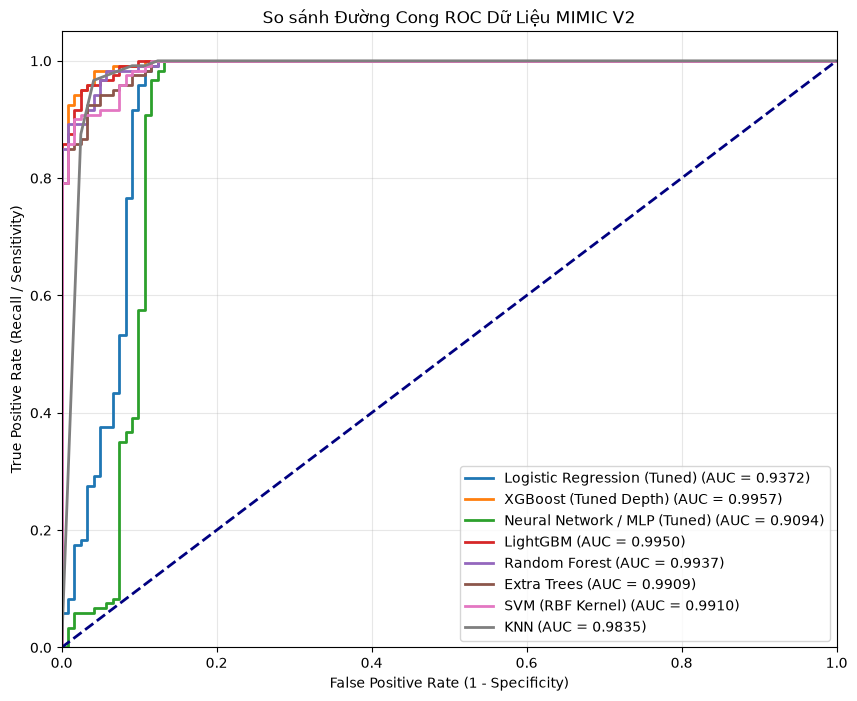

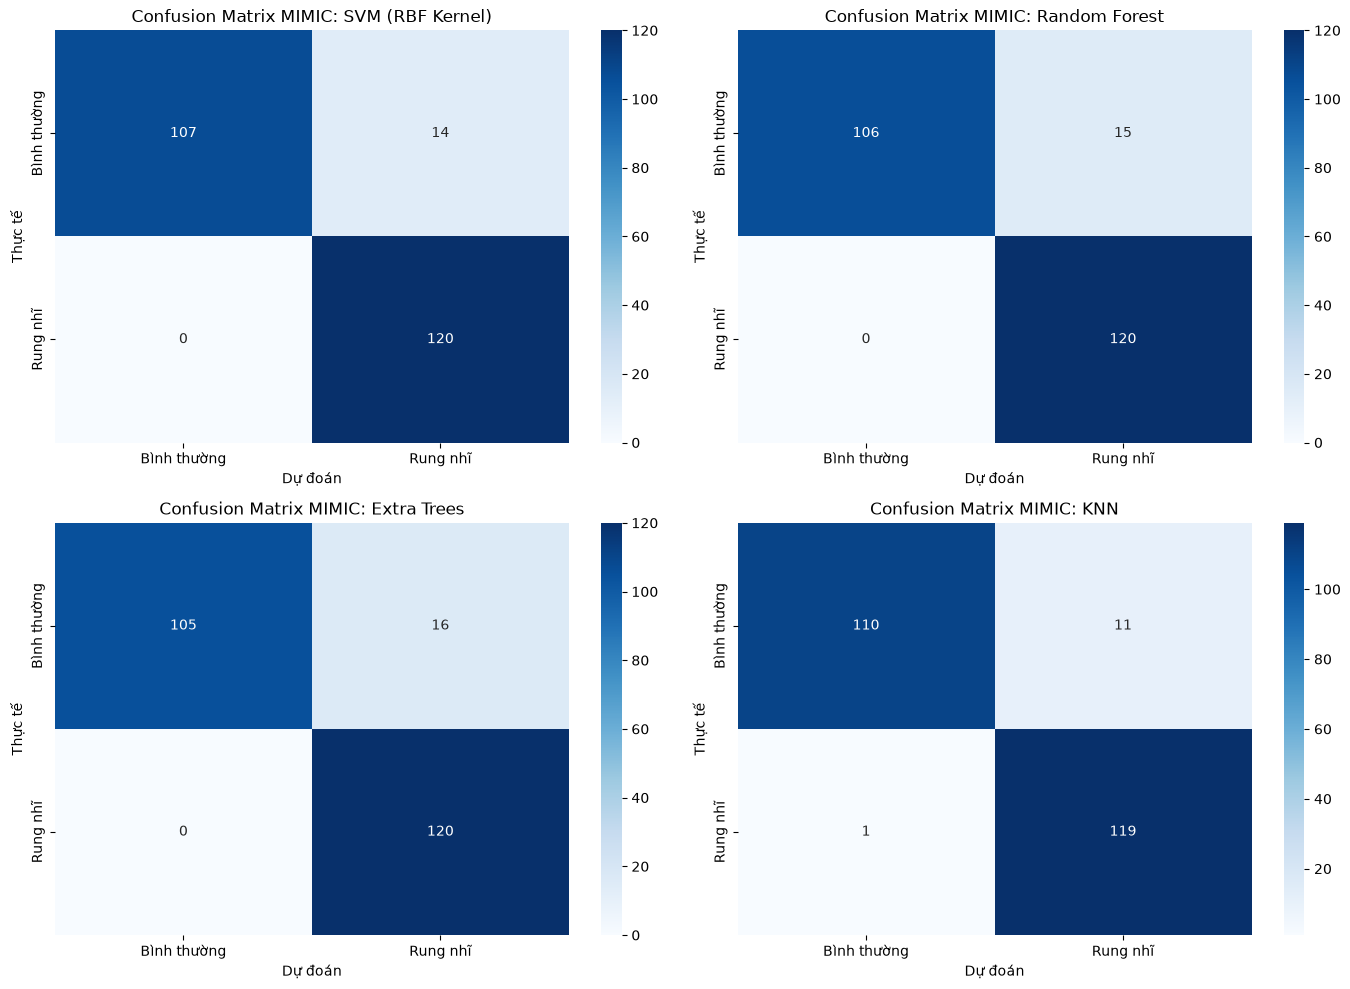

In [6]:
# 1. Trực quan hóa Đường cong ROC Curve MIMIC
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('So sánh Đường Cong ROC Dữ Liệu MIMIC V2')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Confusion Matrices cho Top 4 Mô hình dẫn đầu trên MIMIC
top_4_models = df_eval['Model'].head(4).tolist()
plt.figure(figsize=(14, 10))
for i, model_name in enumerate(top_4_models, 1):
    plt.subplot(2, 2, i)
    sns.heatmap(conf_matrices[model_name], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bình thường', 'Rung nhĩ'],
                yticklabels=['Bình thường', 'Rung nhĩ'])
    plt.title(f'Confusion Matrix MIMIC: {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')

plt.tight_layout()
plt.show()


### 6. Lưu trữ Các Mô Hình Tốt Nhất MIMIC V2

In [7]:
models_v2_dir_candidates = ['../../models/v2/mimic', 'models/v2/mimic']
models_v2_dir = next((d for d in models_v2_dir_candidates if os.path.exists(os.path.dirname(d))), '../../models/v2/mimic')
os.makedirs(models_v2_dir, exist_ok=True)

joblib.dump(best_lr, os.path.join(models_v2_dir, 'logistic_regression_mimic_v2.pkl'))
joblib.dump(best_xgb, os.path.join(models_v2_dir, 'xgboost_mimic_v2.pkl'))
joblib.dump(best_mlp, os.path.join(models_v2_dir, 'neural_network_mlp_mimic_v2.pkl'))

print(f"✅ Đã lưu thành công các mô hình MIMIC V2 vào: {models_v2_dir}")


✅ Đã lưu thành công các mô hình MIMIC V2 vào: ../../models/v2/mimic
